
================= EDA REPORT =================

🔹 Data Shape: (200, 15)

🔹 Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Year               200 non-null    int64 
 1   Region             200 non-null    object
 2   Country            200 non-null    object
 3   State              200 non-null    object
 4   Gender             200 non-null    object
 5   Age_Group          200 non-null    object
 6   Cause              200 non-null    object
 7   Deaths             200 non-null    int64 
 8   Population         200 non-null    int64 
 9   Hospital_Type      200 non-null    object
 10  Urban_Rural        200 non-null    object
 11  Income_Level       200 non-null    object
 12  Healthcare_Access  200 non-null    object
 13  Avg_Temperature    200 non-null    int64 
 14  Pollution_Index    200 non-null    int64 
dtypes: 

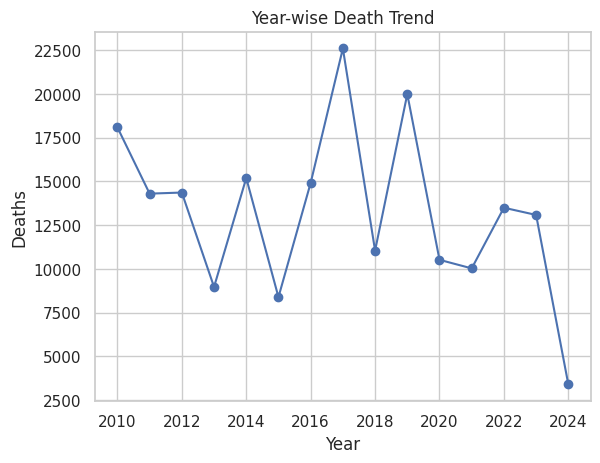

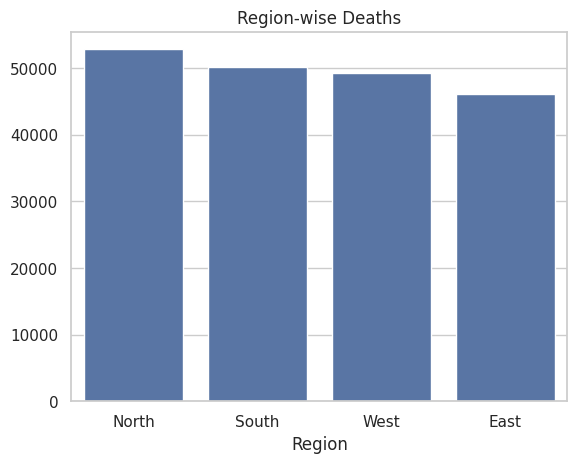

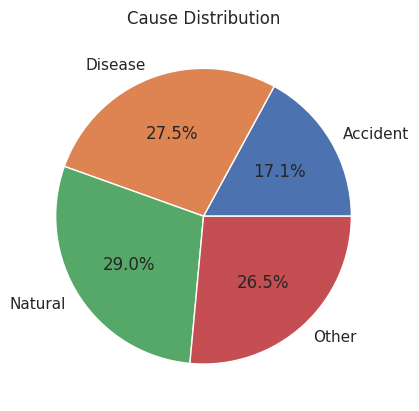

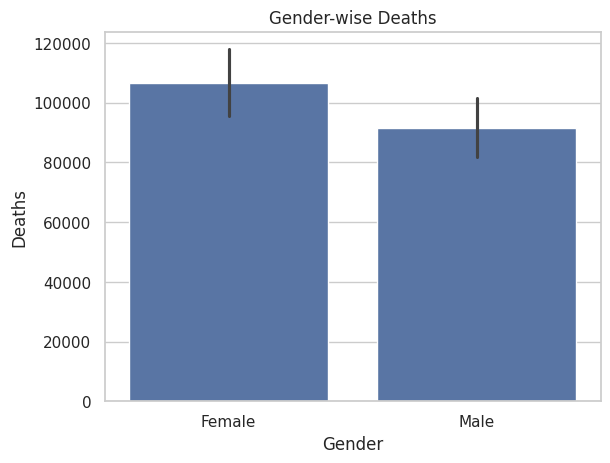

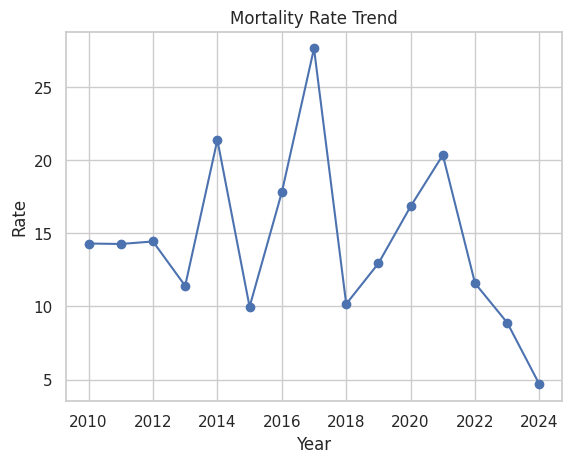

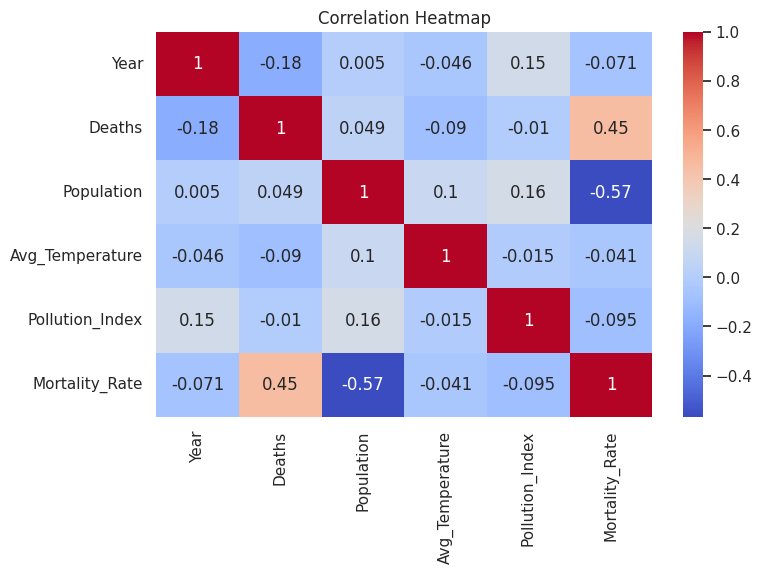


================= KEY INSIGHTS =================

1. Mortality trend varies across years indicating changes in health conditions.
2. Certain regions contribute more to total deaths.
3. Disease-related causes dominate mortality distribution.
4. Gender-wise differences exist in death counts.
5. Mortality rate fluctuates over time showing demographic impact.
6. Correlation shows relation between deaths, population, and environmental factors.

================= END OF REPORT =================



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/content/mortality_data_200x15.csv")

sns.set(style="whitegrid")

print("\n================= EDA REPORT =================\n")

# =========================
# 1. Data Overview
print("🔹 Data Shape:", df.shape)
print("\n🔹 Data Info:\n")
print(df.info())

print("\n🔹 Missing Values:\n")
print(df.isnull().sum())

print("\n🔹 Summary Statistics:\n")
print(df.describe())

# =========================
# 2. Create Mortality Rate (if missing)
if "Mortality_Rate" not in df.columns:
    df["Mortality_Rate"] = (df["Deaths"] / df["Population"]) * 1000

# =========================
# 3. Top Regions Table
top_regions = df.groupby("Region")["Deaths"].sum().sort_values(ascending=False)

print("\n🔹 Top Regions by Deaths:\n")
print(top_regions)

# =========================
# 4. Year-wise Trend
year_data = df.groupby("Year")["Deaths"].sum()

plt.figure()
plt.plot(year_data.index, year_data.values, marker='o')
plt.title("Year-wise Death Trend")
plt.xlabel("Year")
plt.ylabel("Deaths")
plt.show()

# =========================
# 5. Region-wise Deaths
plt.figure()
sns.barplot(x=top_regions.index, y=top_regions.values)
plt.title("Region-wise Deaths")
plt.show()

# =========================
# 6. Cause Distribution
cause_data = df.groupby("Cause")["Deaths"].sum()

plt.figure()
plt.pie(cause_data.values, labels=cause_data.index, autopct='%1.1f%%')
plt.title("Cause Distribution")
plt.show()

# =========================
# 7. Gender Analysis
plt.figure()
sns.barplot(x="Gender", y="Deaths", data=df, estimator=sum)
plt.title("Gender-wise Deaths")
plt.show()

# =========================
# 8. Mortality Rate Trend
rate_data = df.groupby("Year")["Mortality_Rate"].mean()

plt.figure()
plt.plot(rate_data.index, rate_data.values, marker='o')
plt.title("Mortality Rate Trend")
plt.xlabel("Year")
plt.ylabel("Rate")
plt.show()

# =========================
# 9. Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 10. INSIGHTS (AUTO PRINT 🔥)

print("\n================= KEY INSIGHTS =================\n")

print("1. Mortality trend varies across years indicating changes in health conditions.")
print("2. Certain regions contribute more to total deaths.")
print("3. Disease-related causes dominate mortality distribution.")
print("4. Gender-wise differences exist in death counts.")
print("5. Mortality rate fluctuates over time showing demographic impact.")
print("6. Correlation shows relation between deaths, population, and environmental factors.")

print("\n================= END OF REPORT =================\n")